# An ergodic target that only expands: the 2-DoF key-in-lock toy

The lock, the cloud and the E2T2 law of `Ergodic_Exploration_phase_key_in_lock_2D.ipynb`. The master is still the
description of progress, but the target no longer moves along it and forgets what is behind:

- the **phase** $\varphi$ is the furthest the robot has come along the master, and never decreases;
- the **target** is every cloud point with a phase up to $\varphi + \sigma_f$, equally weighted. Progress adds the
  next slice; without progress the target stays as it is;
- the **statistic** is E2T2's plain time average of every state so far.

There is no stall counter, no $\sigma_b$, no $\beta$, no clock and no step-back: the law is E2T2 on a target that grows.
A new slice is the part of the target not yet covered, which is the forward pull; a stuck robot goes on covering
everything it has reached.

In [1]:
import math
from dataclasses import dataclass

import numpy as np
from matplotlib import pyplot as plt

## 1. The E2T2 law, unchanged

$b_i = \sum_{\mathbf k} \Lambda_{\mathbf k} (\mathcal W_{\mathbf k} - \hat{\mathcal W}_{\mathbf k}) \nabla_i \Phi_{\mathbf k}(z)$,
$u = -u_{\max}\, b / \|b\|$, as in the phase notebook.

In [2]:
def basis(z, K):  # (M,) -> (M, K)
    return np.cos(np.pi * np.outer(z, np.arange(K)))


def basis_derivative(z, K):  # (M,) -> (M, K)
    k = np.arange(K)
    return -np.pi * k * np.sin(np.pi * np.outer(z, k))


def optimisation_weights(K, d=2):  # (K, K)
    k = np.arange(K)
    return (1.0 + k[:, None] ** 2 + k[None, :] ** 2) ** (-(d + 1) / 2)


def pull2centre(z, alpha=20.0, c=1.0 / 20):
    weight = np.tanh(alpha * (z - c)) / 2 + np.tanh(alpha * (1 - c - z)) / 2
    dz = -np.tanh(alpha * (z - c)) / 2 + np.tanh(alpha * (1 - c - z)) / 2
    return weight, dz


def ergodic_direction(z, D, lam):
    """E2T2's step direction at cube state z (2,), D = W - W_hat (K, K): unit length."""
    K = D.shape[0]
    phi_x, phi_t = basis(z[:1], K)[0], basis(z[1:], K)[0]
    dphi_x, dphi_t = basis_derivative(z[:1], K)[0], basis_derivative(z[1:], K)[0]
    LD = lam * D
    b = np.array([dphi_x @ LD @ phi_t, phi_x @ LD @ dphi_t])
    u = -b / (np.linalg.norm(b) + 1e-10)
    weight, centre = pull2centre(z)
    centre = centre / (np.linalg.norm(centre) + 1e-8)
    u = u * weight + centre * (1 - weight)
    return u / (np.linalg.norm(u) + 1e-8)


# Gradient check: phi'(z) against a central difference of phi(z).
_z, _eps = np.array([0.137, 0.71]), 1e-6
_fd = (basis(_z + _eps, 12) - basis(_z - _eps, 12)) / (2 * _eps)
print("max |dphi - finite difference|:", np.abs(basis_derivative(_z, 12) - _fd).max())
assert np.allclose(basis_derivative(_z, 12), _fd, atol=1e-6)

max |dphi - finite difference|: 7.01666635904985e-09


## 2. World, cloud and master

As the phase notebook, except that the master's phase is its **normalised arc length**: 8 scaled units of
insertion, then 9 of turning, so $\varphi = 8/17$ at the corner. Equal phase is equal travel, which is what the
clock's speed assumes.

In [3]:
THETA_SCALE = 10.0  # degrees per scaled unit


def metric(x, theta_deg):  # world (x, deg) -> scaled s, (..., 2)
    return np.stack(np.broadcast_arrays(x, np.asarray(theta_deg) / THETA_SCALE), axis=-1)


S_LO = np.array([-1.5, -5.5])  # scaled box of the cube
S_SPAN = 19.0


def to_cube(s):
    return (s - S_LO) / S_SPAN


def lcg(seed, a, c, m):
    """The prototype's generator, in doubles as JavaScript computes it."""
    state = float(seed)

    def draw():
        nonlocal state
        state = (state * a + c) % m
        return state / m

    return draw


def gauss(rnd):
    u = rnd() or 1e-9
    v = rnd()
    return math.sqrt(-2 * math.log(u)) * math.cos(2 * math.pi * v)


N_INSERTION = 500  # cloud points of the insertion, ahead of the turning and end-state ones


def make_cloud():  # (800, 2) scaled
    rnd = lcg(7, 1664525.0, 1013904223.0, 4294967296.0)
    points = []
    for _ in range(N_INSERTION):  # insertion
        p = -0.03 + rnd() * 0.53
        x = 16 * p + gauss(rnd) * 0.3
        points.append((x, min(35.0, max(-35.0, gauss(rnd) * 14))))
    for _ in range(260):  # turning
        x = min(8.25, 8 + gauss(rnd) * 0.15)
        points.append((x, rnd() * 102 + gauss(rnd) * 6))
    for _ in range(40):  # demonstration end states: where phi = 1 is
        x = 8 - abs(gauss(rnd)) * 0.05
        points.append((x, 90 + gauss(rnd) * 1.5))
    points = np.array(points)
    return metric(points[:, 0], points[:, 1])


LENGTH = 8.0 + 9.0  # scaled units: the insertion, then a 90 deg turn
PHI_GRID = np.linspace(0.0, 1.0, 401)


def master_path(phi):  # (M,) -> (M, 2) scaled
    a = np.atleast_1d(phi) * LENGTH
    return np.column_stack([np.minimum(a, 8.0), np.maximum(a - 8.0, 0.0)])


MASTER = master_path(PHI_GRID)


def project(s):
    """Phase of the master sample nearest to s (..., 2): where on the task the state is."""
    d = ((MASTER - np.asarray(s)[..., None, :]) ** 2).sum(axis=-1)
    return PHI_GRID[np.argmin(d, axis=-1)]


CLOUD = make_cloud()
PHI_CLOUD = project(CLOUD)


def author(kappa):
    """The master and cloud as demonstrated on a lock whose keyway is at kappa (deg): the turn starts there.

    The insertion is the search and stays around 0 deg; the phases stay PHI_CLOUD, those of the original master.
    """
    shift = np.array([0.0, kappa / THETA_SCALE])
    master, cloud = MASTER.copy(), CLOUD.copy()
    master[PHI_GRID * LENGTH > 8.0] += shift
    cloud[N_INSERTION:] += shift
    return master, cloud


# Arc length: the samples are equally spaced, but for the one chord that cuts the corner.
_steps = np.linalg.norm(np.diff(MASTER, axis=0), axis=1)
assert np.isclose(_steps, LENGTH / 400).sum() == 399 and LENGTH - _steps.sum() < LENGTH / 400
# The authored turn runs from (8, kappa) to (8, kappa + 90 deg), and the insertion is the original's.
_master, _cloud = author(14.0)
assert np.allclose(_master[-1], (8.0, 10.4)) and np.allclose(_master[PHI_GRID * LENGTH > 8.0][0], (8.0, 1.4), atol=LENGTH / 400)
assert (_master[PHI_GRID * LENGTH <= 8.0] == MASTER[PHI_GRID * LENGTH <= 8.0]).all() and (_cloud[:N_INSERTION] == CLOUD[:N_INSERTION]).all()
assert np.allclose(_cloud[N_INSERTION:] - CLOUD[N_INSERTION:], (0.0, 1.4))

## 3. Every number, and where it comes from

| quantity | value | source |
|---|---|---|
| $h$ | median distance to the $k$-th nearest cloud point, $k = \mathrm{round}(\sqrt N)$ | the cloud |
| $\sigma_f = h / \ell$ | the cloud's resolution as a phase: the target's lead and the width of its front edge | the cloud and the master's length $\ell$ |

Left as chosen: $K = 10$ Fourier modes, memory every third step, and the phase estimator's window of the phase notebook.

In [4]:
V_MAX = 0.07  # scaled units per step
NOISE = 0.25  # actuator noise is uniform in +-NOISE/2 per axis

_k = round(math.sqrt(len(CLOUD)))
_pairwise = np.hypot(*(CLOUD[:, None, :] - CLOUD[None, :, :]).transpose(2, 0, 1))
np.fill_diagonal(_pairwise, np.inf)
H = np.median(np.sort(_pairwise, axis=1)[:, _k - 1])
SIGMA_F = H / LENGTH
K = 10
LAMBDA = optimisation_weights(K)

print(f"h = {H:.4f} scaled units, sigma_f = lead = {SIGMA_F:.4f}")

h = 0.7500 scaled units, sigma_f = lead = 0.0441


## 4. Lock physics

The phase notebook's, with its false keyway: a second keyway that takes the key and holds $\theta$ but ends at
$x = 6$, short of where the key can turn.

In [5]:
FACE, DEPTH = 3.0, 8.0
TURN_DEPTH = DEPTH - 0.2  # the key can turn from here
FALSE_DEPTH = 6.0  # where the false keyway ends, short of TURN_DEPTH
KEYWAY_TOL = 4.0 / THETA_SCALE
TURNED = 0.5 / THETA_SCALE  # beyond this the key is held in
JAM_RELEASE = FACE - 0.12
SUCCESS_TURN = 89.0 / THETA_SCALE
THETA_LIMITS = (-5.0, 13.0)  # scaled


@dataclass
class Lock:
    kt: float  # keyway angle, scaled
    inside: bool = False
    jam: bool = False
    false_kt: float | None = None  # a second keyway's angle, scaled: a dead end
    in_false: bool = False


def _inside_step(lock, s, nx, nt):
    if s[0] < TURN_DEPTH:
        nt = lock.kt
    else:
        nt = max(lock.kt, nt)
        if nt > lock.kt + TURNED:
            nx = max(nx, TURN_DEPTH)
    nx = min(DEPTH, nx)
    if nx < FACE:
        if nt <= lock.kt + TURNED:
            lock.inside = False
        else:
            nx = FACE + 0.01
    return nx, nt


def _false_step(lock, s, nx, nt):
    """In the false keyway: theta held as in the true one, but it ends at FALSE_DEPTH."""
    lock.in_false = nx >= FACE
    return min(FALSE_DEPTH, nx), lock.false_kt


def _outside_step(lock, s, nx, nt):
    if lock.jam and s[0] > JAM_RELEASE:
        nt = s[1]
    if nx >= FACE:
        if abs(nt - lock.kt) < KEYWAY_TOL:
            lock.inside, lock.jam = True, False
            nt, nx = lock.kt, min(nx, DEPTH)
        elif lock.false_kt is not None and abs(nt - lock.false_kt) < KEYWAY_TOL:
            lock.in_false, lock.jam = True, False
            nt, nx = lock.false_kt, min(nx, FALSE_DEPTH)
        else:
            nx, lock.jam = FACE, True
    if lock.jam and nx < JAM_RELEASE:
        lock.jam = False
    return nx, nt


def lock_step(lock, s, s_new):
    """The pose the lock lets the robot reach from s when it commands s_new."""
    step = _inside_step if lock.inside else _false_step if lock.in_false else _outside_step
    nx, nt = step(lock, s, s_new[0], s_new[1])
    return np.array([nx, min(THETA_LIMITS[1], max(THETA_LIMITS[0], nt))])


# Small tests of the pure functions.
_lock = Lock(kt=metric(0, 14.0)[1])
assert lock_step(_lock, np.array([2.95, 0.0]), np.array([3.02, 0.0]))[0] == FACE and _lock.jam
assert (
    lock_step(_lock, np.array([2.95, 0.0]), np.array([2.97, 0.5]))[1] == 0.0
)  # jammed: theta frozen
_lock = Lock(kt=1.4)
assert lock_step(_lock, np.array([2.95, 1.4]), np.array([3.02, 1.5]))[1] == 1.4 and _lock.inside
_lock = Lock(kt=1.4, inside=True)
assert (
    lock_step(_lock, np.array([7.9, 3.0]), np.array([7.0, 3.0]))[0] == TURN_DEPTH
)  # turned: held in
_lock = Lock(kt=1.4, false_kt=0.0)
_s = lock_step(_lock, np.array([2.95, 0.1]), np.array([3.05, 0.1]))
assert _lock.in_false and not _lock.inside and _s[1] == 0.0
_s = lock_step(_lock, _s, np.array([9.0, 2.0]))  # false keyway: stopped at its end, no turning
assert tuple(_s) == (FALSE_DEPTH, 0.0)
_s = lock_step(_lock, _s, np.array([2.9, 0.3]))  # and free again once back out past the face
assert not _lock.in_false and tuple(_s) == (2.9, 0.0)
print("physics tests passed")

physics tests passed


## 5. The law

**Phase.** $\hat\varphi$ is the phase of the master sample nearest to the robot, searched over
$[\varphi - 0.05,\ \varphi + 0.12]$, and $\varphi \leftarrow \max(\varphi, \hat\varphi)$.

**Target.** With $d_j = \varphi_j - \min(1, \varphi + \sigma_f)$, a cloud point is reached to the degree

$$r_j(\varphi) = \begin{cases} 1 & d_j \le 0 \\ \exp(-d_j^2 / 2\sigma_f^2) & d_j > 0 \end{cases}$$

and $\hat{\mathcal W} = \sum_j r_j \Phi(z_j) / \sum_j r_j$. This is the phase notebook's kernel with $\sigma_b = \infty$.
$r_j$ never decreases as $\varphi$ grows, so nothing leaves the target.

**Statistic.** $\mathcal W = \frac{1}{n} \sum_m \Phi(z_m)$ over every stored state, as in E2T2.

`front_share`, 0.25 by default: that share of the target's mass goes to the newest slice alone, the
phase notebook's kernel of width $\sigma_f$ on both sides, and the rest to everything reached. The support is the same.

In [6]:
MEMORY_EVERY = 3
STEPS = 5000
PHASE_WINDOW = (0.05, 0.12)  # phases the estimator may look back and ahead of phi


def reached(phi):  # (N,) in (0, 1]: how far each cloud point is inside the target
    d = PHI_CLOUD - min(1.0, phi + SIGMA_F)
    return np.where(d > 0, np.exp(-(d**2) / (2 * SIGMA_F**2)), 1.0)


def front(phi):  # (N,): the newest slice alone
    return np.exp(-((PHI_CLOUD - min(1.0, phi + SIGMA_F)) ** 2) / (2 * SIGMA_F**2))


def coefficients(z, a):  # (M, 2) cube states, (M,) weights -> (K, K)
    return (basis(z[:, 0], K) * a[:, None]).T @ basis(z[:, 1], K)


class Run:
    # One episode: the robot, the lock, the phase and the law.

    front_share = 0.25
    goal_authored_turn = True  # the master and cloud turn up from the lock's keyway angle, not from 0 deg
    forget_window = 800  # steps the statistic remembers; None is the plain time average

    def __init__(self, kappa, seed=3, false_kappa=None):
        self.lock = Lock(kt=float(metric(0.0, kappa)[1]))
        if false_kappa is not None:
            self.lock.false_kt = float(metric(0.0, false_kappa)[1])
        self.noise = lcg(seed, 1103515245.0, 12345.0, 2147483648.0)
        self.master, self.cloud = author(kappa) if self.goal_authored_turn else (MASTER, CLOUD)
        self.s, self.phi = np.array([-0.6, 0.0]), 0.0
        self.memory, self.W_sum = [], np.zeros((K, K))  # stored states (x, theta) and their sum of Phi
        self.mass = 0.0  # the stored states' total weight in W_sum: their number, unless they are forgotten
        self.log = []  # (x, theta, phi, share of the cloud reached)
        self.n, self.done, self.false_entries, self.entered = 0, False, 0, False

    def target_weights(self):  # (N,), of mass 1
        r, f = reached(self.phi), front(self.phi)
        return (1 - self.front_share) * r / r.sum() + self.front_share * f / f.sum()

    def statistic(self):  # (K, K), of mass 1; empty before the first stored state
        return self.W_sum / self.mass if self.memory else self.W_sum

    def advance_phase(self):
        d = ((self.master - self.s) ** 2).sum(axis=1)
        d[(self.phi - PHASE_WINDOW[0] > PHI_GRID) | (self.phi + PHASE_WINDOW[1] < PHI_GRID)] = np.inf
        self.phi = max(self.phi, float(PHI_GRID[np.argmin(d)]))

    def step(self):
        W_hat = coefficients(to_cube(self.cloud), self.target_weights())
        u = V_MAX * ergodic_direction(to_cube(self.s), self.statistic() - W_hat, LAMBDA)
        u = u + (np.array([self.noise(), self.noise()]) - 0.5) * NOISE
        speed = np.hypot(*u)
        u = u * V_MAX / speed if speed > V_MAX else u
        in_false = self.lock.in_false
        self.s = lock_step(self.lock, self.s, self.s + u)
        self.false_entries += self.lock.in_false and not in_false
        self.entered = self.entered or self.lock.inside
        self.advance_phase()
        if self.n % MEMORY_EVERY == 0:
            keep = 1.0 if self.forget_window is None else 1.0 - MEMORY_EVERY / self.forget_window
            self.memory.append(self.s)
            self.W_sum = keep * self.W_sum + coefficients(to_cube(self.s[None]), np.ones(1))
            self.mass = keep * self.mass + 1.0
        self.log.append((*self.s, self.phi, reached(self.phi).mean()))
        self.n += 1
        self.done = self.lock.inside and self.s[1] >= self.lock.kt + SUCCESS_TURN

    def run(self):
        while not self.done and self.n < STEPS:
            self.step()
        return self


# The target only grows: no cloud point is reached less at a later phase, and those behind the front stay at 1.
_phis = np.linspace(0.0, 1.0, 101)
_r = np.array([reached(p) for p in _phis])
assert (np.diff(_r, axis=0) >= 0).all()
assert (_r[40:, _phis[40] + SIGMA_F >= PHI_CLOUD] == 1.0).all() and (_r[-1] == 1.0).all()
# The phase only grows, and a robot that goes back leaves it, and so the target, where they were.
_run = Run(0.0)
_run.s = master_path(0.1)[0]
_run.advance_phase()
_target = _run.target_weights()
_run.s = master_path(0.02)[0]
_run.advance_phase()
assert math.isclose(_run.phi, 0.1) and (_run.target_weights() == _target).all()
# The running statistic against the mean of Phi over the stored states.
_run = type("Plain", (Run,), {"forget_window": None})(14.0, seed=4)
for _ in range(300):
    _run.step()
_mean = coefficients(to_cube(np.array(_run.memory)), np.full(len(_run.memory), 1 / len(_run.memory)))
assert np.allclose(_run.statistic(), _mean, atol=1e-12) and np.isclose(_run.statistic()[0, 0], 1.0)
# The forgetting statistic against the weighted mean with weights lambda^age, written out.
_run = Run(14.0, seed=4)
for _ in range(300):
    _run.step()
_age = np.arange(len(_run.memory))[::-1]
_discount = (1 - MEMORY_EVERY / Run.forget_window) ** _age
_mean = coefficients(to_cube(np.array(_run.memory)), _discount / _discount.sum())
assert np.allclose(_run.statistic(), _mean, atol=1e-12) and np.isclose(_run.mass, _discount.sum())
print("target, phase and statistic tests passed")

target, phase and statistic tests passed


## 6. Three runs

Free insertion ($\kappa = 0°$), a jam at the face ($\kappa = 14°$), and the false keyway at $0°$ with the true one
at $14°$. Left: the path in $(x, \theta)$. Right: the phase, and the share of the cloud the target has reached.

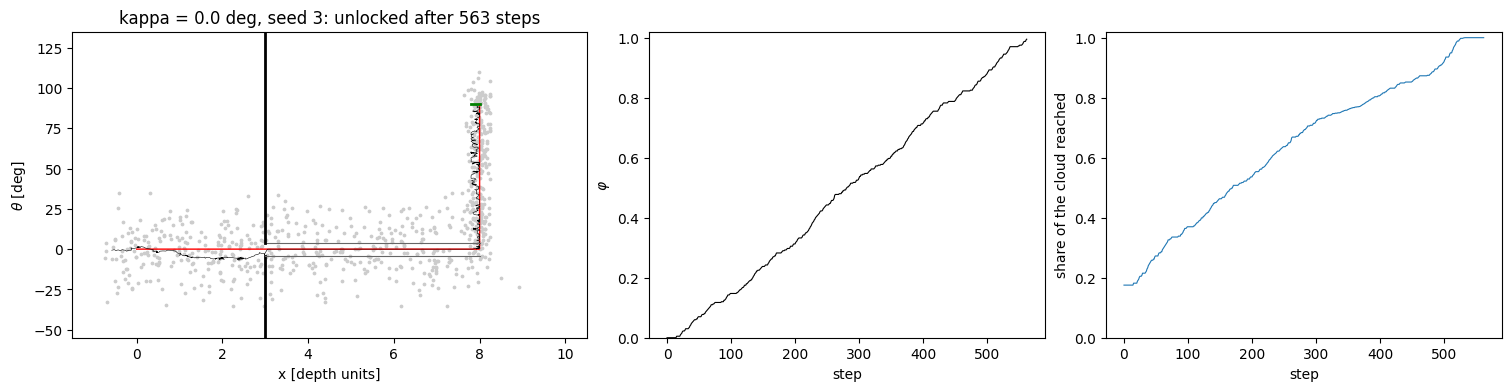

0 entries into the false keyway, final phase 0.995


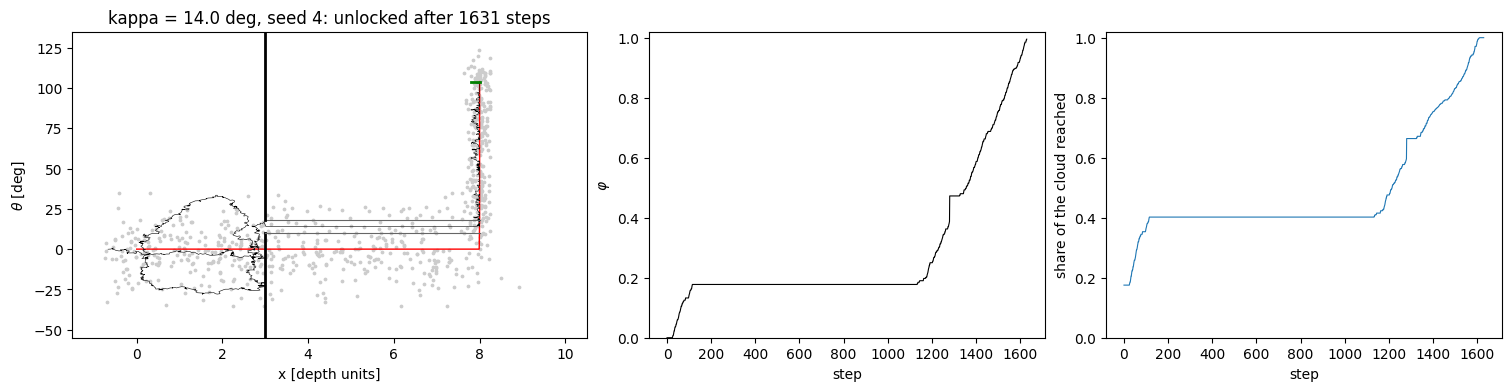

0 entries into the false keyway, final phase 0.995


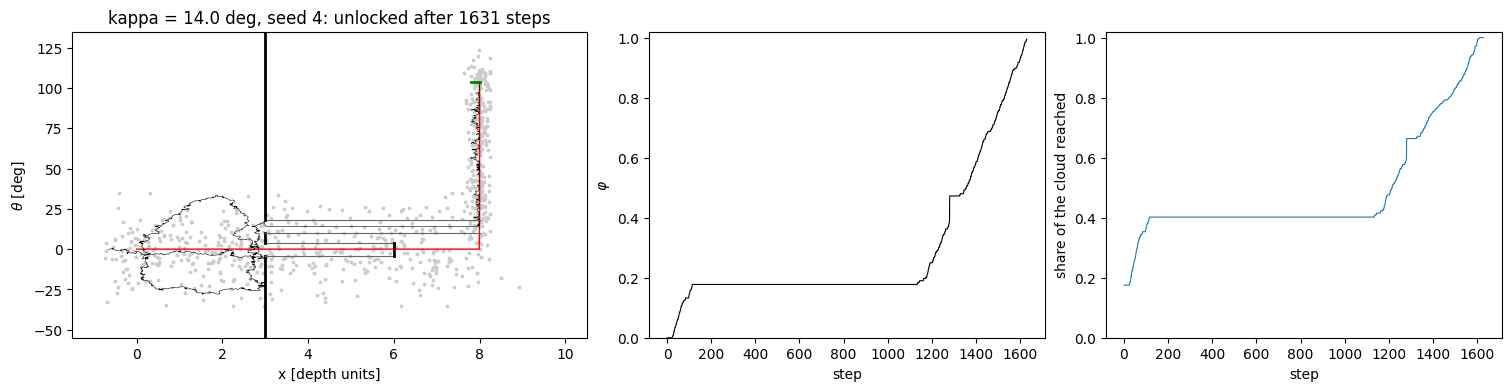

0 entries into the false keyway, final phase 0.995


In [7]:
def draw_lock(ax, kappa, false_kappa=None):
    """The face with a gap of +-4 deg per keyway; the false one is closed off at FALSE_DEPTH."""
    keyways = sorted([(kappa, DEPTH)] + ([] if false_kappa is None else [(false_kappa, FALSE_DEPTH)]))
    edge = -55
    for angle, depth in keyways:
        lo, hi = angle - 4, angle + 4
        ax.plot([FACE, FACE], [edge, lo], "-k", lw=2)
        ax.plot([FACE, depth], [lo, lo], "-", color="0.4", lw=0.8)
        ax.plot([FACE, depth], [hi, hi], "-", color="0.4", lw=0.8)
        if depth < DEPTH:
            ax.plot([depth, depth], [lo, hi], "-k", lw=2)
        edge = hi
    ax.plot([FACE, FACE], [edge, 135], "-k", lw=2)
    ax.plot([TURN_DEPTH, DEPTH], [kappa + 90, kappa + 90], "-g", lw=2, label="90 deg stop")



def show_run(kappa, seed, false_kappa=None, **flags):
    run = type("Variant", (Run,), flags)(kappa, seed=seed, false_kappa=false_kappa).run()
    log = np.array(run.log)
    fig, (world, phase, share) = plt.subplots(
        1, 3, figsize=(15, 3.8), width_ratios=[1.3, 1, 1], layout="constrained"
    )
    world.scatter(run.cloud[:, 0], run.cloud[:, 1] * THETA_SCALE, s=3, c="0.8")
    world.plot(run.master[:, 0], run.master[:, 1] * THETA_SCALE, "-r", lw=1, label="master")
    world.plot(log[:, 0], log[:, 1] * THETA_SCALE, "-k", lw=0.4)
    draw_lock(world, kappa, false_kappa)
    world.set(xlim=(-1.5, 10.5), ylim=(-55, 135), xlabel="x [depth units]", ylabel=r"$\theta$ [deg]")
    phase.plot(log[:, 2], "-k", lw=0.8)
    phase.set(xlabel="step", ylabel=r"$\varphi$", ylim=(0, 1.02))
    share.plot(log[:, 3], lw=0.8)
    share.set(xlabel="step", ylabel="share of the cloud reached", ylim=(0, 1.02))
    world.set_title(
        f"kappa = {kappa} deg, seed {seed}: {'unlocked' if run.done else 'not unlocked'} after {run.n} steps"
    )
    plt.show()
    print(f"{run.false_entries} entries into the false keyway, final phase {run.phi:.3f}")
    return run


_ = show_run(0.0, seed=3)
_ = show_run(14.0, seed=4)
_ = show_run(14.0, seed=4, false_kappa=0.0)

## 7. Sweep

$\kappa \in \{-20, \dots, 20\}$ with 5 noise seeds, 5000 steps a run: 35 runs on the plain lock, and 30 with the
false keyway at $0°$ ($\kappa = 0°$ left out, where the two keyways coincide).

In [8]:
KAPPAS = [-20, -14, -8, 0, 8, 14, 20]
SEEDS = [3, 4, 5, 6, 7]
OTHER_KAPPAS = [k for k in KAPPAS if k != 0]


def outcome_table(runs, kappas):
    rows = [f"{'kappa':>8}" + "".join(f"{k:>7}" for k in kappas)]
    for seed in SEEDS:
        cells = (runs[k, seed] for k in kappas)
        rows.append(f"{f'seed {seed}':>8}" + "".join(f"{r.n if r.done else 'no':>7}" for r in cells))
    return "\n".join(rows)


def sweep(**flags):
    variant = type("Variant", (Run,), flags)
    plain = {(k, s): variant(k, seed=s).run() for k in KAPPAS for s in SEEDS}
    false = {(k, s): variant(k, seed=s, false_kappa=0.0).run() for k in OTHER_KAPPAS for s in SEEDS}
    print(
        f"plain {sum(r.done for r in plain.values()):>2}/35, false keyway {sum(r.done for r in false.values()):>2}/30, "
        f"{np.mean([r.false_entries for r in false.values()]):4.1f} entries a run"
    )
    return plain, false


OLD = {"goal_authored_turn": False, "forget_window": None}  # the law of Section 8

for share in (0.0, 0.25, 0.5, 0.75):
    print(f"front share {share}: ", end="")
    plain, false = sweep(front_share=share, **OLD)
    if share == 0.0:
        print(f"steps to unlock, plain lock\n{outcome_table(plain, KAPPAS)}")
        print(f"steps to unlock, false keyway at 0 deg\n{outcome_table(false, OTHER_KAPPAS)}\n")

front share 0.0: 

plain 15/35, false keyway  9/30,  3.0 entries a run
steps to unlock, plain lock
   kappa    -20    -14     -8      0      8     14     20
  seed 3     no   2359     no    586     no     no     no
  seed 4   1979   1446    539     no     no     no     no
  seed 5   4046   4052   4043    576     no     no     no
  seed 6   3496   3325     no    678     no     no     no
  seed 7   3755     no    546    634     no     no     no
steps to unlock, false keyway at 0 deg
   kappa    -20    -14     -8      8     14     20
  seed 3     no     no     no     no     no     no
  seed 4   1979   1446    539     no     no     no
  seed 5   1032   1270     no     no     no     no
  seed 6   1107     no     no     no     no     no
  seed 7   1840   1862    546     no     no     no

front share 0.25: 

plain 29/35, false keyway 16/30,  2.5 entries a run
front share 0.5: 

plain 24/35, false keyway 10/30,  1.4 entries a run
front share 0.75: 

plain 19/35, false keyway  2/30,  1.1 entries a run


## 8. Results

| law | plain lock | false keyway |
|---|---|---|
| expanding target | 15/35 | 9/30 |
| expanding target, front share 0.25 | 29/35 | 16/30 |
| expanding target, front share 0.5 | 24/35 | 10/30 |
| expanding target, front share 0.75 | 19/35 | 2/30 |
| phase notebook's law | 25/35 | 16/30 |
| reference tracking, step-back on / off | 30/35 / 23/35 | 2/30 / 19/30 |

- **The expanding target alone is worse than both earlier laws**: 15/35 and 9/30.
- **Without progress it does what it should.** At the face $\varphi$ stays at 0.18, the target at 40 % of the cloud,
  and the robot covers $\theta$ from $-35°$ to $35°$ until it meets the keyway.
- **Free insertion works**: $\kappa = 0°$ unlocks in 576 to 678 steps on four of five seeds.
- **No keyway at $\kappa > 0$ is ever unlocked** (0/15). The second run of Section 6 finds the keyway and inserts, and then
  stays in it: $\varphi$ ends at 0.568, a few degrees into the turn.
- **Why, as far as the runs show.** The new slice is $\sigma_f$ of phase, a small part of a target that now holds
  everything reached, all at equal weight. The time spent outside counts as coverage of the outside only, so once inside the
  whole keyway is uncovered and the law covers it back and forth instead of going on to the turn. The forward pull is only as
  strong as the new slice's share of the target.
- **A quarter of the target's mass on the newest slice gives 29/35 and 16/30**, the phase law's false-keyway result with
  no stall counter, $\sigma_b$ or $\beta$. More than that loses it again: at 0.75 the false keyway is 2/30, as with the
  step-back. The share is a knob, tried at three values on these 65 runs and not derived from anything.


## 9. Authored turn and forgetting

Two changes, each a flag of `Run` and on by default:

- `goal_authored_turn`: the master's turn and the cloud's turning and end-state points start at the keyway angle
  $\kappa$, as a demonstration on that lock would. Built per lock before the run; the law never reads $\kappa$.
- `forget_window`: the statistic is discounted by $\lambda = 1 - 3 / \text{window}$ per stored state.

A run is *frozen* if it ends turned but not unlocked, and *never inside* if it never entered the true keyway.

In [9]:
def ablation_row(label, **flags):
    variant = type("Variant", (Run,), flags)
    plain = [variant(k, seed=s).run() for k in KAPPAS for s in SEEDS]
    false = [variant(k, seed=s, false_kappa=0.0).run() for k in OTHER_KAPPAS for s in SEEDS]
    cells = []
    for runs in (plain, false):
        steps = [r.n for r in runs if r.done]
        frozen = sum(not r.done and r.lock.inside and r.s[1] > r.lock.kt + TURNED for r in runs)
        cells.append(
            f"{len(steps):>2}/{len(runs)} {frozen:>6} {sum(not r.entered for r in runs):>12} {np.median(steps):>7.0f}"
        )
    print(f"{label:<27}" + "   |   ".join(cells))


print(f"{'':<27}" + "   |   ".join(f"{name:<5} frozen never inside  median" for name in ("plain", "false")))
for share in (0.0, 0.25):
    print(f"front share {share}")
    ablation_row("(a) old behaviour", front_share=share, **OLD)
    ablation_row("(b) + authored turn", front_share=share, forget_window=None)
    ablation_row("(c) + forgetting 800", front_share=share)
    ablation_row("(c) with forgetting 400", front_share=share, forget_window=400)
    ablation_row("(c) with forgetting 1500", front_share=share, forget_window=1500)

                           plain frozen never inside  median   |   false frozen never inside  median
front share 0.0


(a) old behaviour          15/35      2            1    1979   |    9/30      3            6    1270


(b) + authored turn        19/35      1            1    1803   |   13/30      1            8    1438


(c) + forgetting 800       21/35      1            1    2098   |   21/30      0            0    1547


(c) with forgetting 400    20/35      1            4    1852   |   18/30      0            2    1217


...

(a) old behaviour          29/35      4            1    1703   |   16/30      2            9    1618


(b) + authored turn        32/35      1            1    1751   |   25/30      1            3    1716


(c) + forgetting 800       30/35      2            0    1624   |   25/30      2            2    1730


(c) with forgetting 400    31/35      0            2    1494   |   21/30      0            7    1605


(c) with forgetting 1500   28/35      2            2    1687   |   20/30      3            6    2593
